# Bound Bias Correction

**Translation of `makePigeon_biasCorrections.m`**

## What this notebook does

The bound-inference algorithm in `pigeon.data.get_bounds` estimates the decision bound
from the midpoint between the pigeon's last two step positions. This estimate is
systematically biased: at short decision times (DT) or low SNR, the inferred bound
tends to deviate from the true generative bound.

This notebook characterizes and corrects that bias:

1. **Simulate**: For each combination of (SNR, true bound), simulate 1 million trials
   with a known generative bound.
2. **Infer**: Apply the same bound-inference algorithm used on real data to recover
   an *inferred* bound for each trial.
3. **Summarize**: Compute the mean inferred bound per DT bin.
4. **Fit**: For each (DT, SNR) bin, fit a linear regression
   `true = intercept + slope × measured` mapping measured → true bounds.
5. **Save**: Write the regression coefficients to `boundBiasCorrection.mat`.
   This file is loaded automatically by `pigeon.data.apply_bias_corrections` when
   real data are read in via `get_data_table(correct_bias='boundBiasCorrection.mat')`.
6. **Visualize**: Plot measured vs. true bound curves per (DT, SNR) cell, with
   the fitted regression and the corrected curve overlaid.

**Parameters match `makePigeon_biasCorrections.m`:**
- 1,000,000 trials per simulation run
- True bounds: 0.01 : 0.05 : 0.71 (15 values)
- Generative means: [0.05, 0.10, 0.15] (→ SNR = mean/std = [0.33, 0.67, 1.0])
- Generative std: 0.15 (shared)
- NDT range: 1–3 steps
- Max DT bins: 12

## Imports and parameters

Sets up all simulation parameters. `SIM_BOUNDS` are the true generative bounds tested.
`GENERATIVE_MEANS` are the per-step drift rates; SNR = mean / std.
No data filtering is applied here — this cell only defines constants.

In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
import scipy.io
import matplotlib.pyplot as plt

from pigeon.simulate import simulate_trials
from pigeon.data import get_bounds_from_dv
from pigeon.pathDefaults import BIAS_CORRECTION_FILE as OUTPUT_FILE

# ── Parameters matching MATLAB makePigeon_biasCorrections.m ──────────────────
NUM_TRIALS       = 1_000_000               # trials per simulation run
SIM_BOUNDS       = np.arange(0.01, 0.72, 0.05)  # [0.01, 0.06, ..., 0.71] — 15 values
GENERATIVE_MEANS = np.array([0.05, 0.10, 0.15]) # per-step drift means
GENERATIVE_STD   = 0.15                    # per-step drift std (shared)
MAX_STEPS        = 50                      # max steps per simulated trial
MAX_RT           = 12                      # DT bins 1..12
MAX_NDT          = 5                       # max NDT lag for bound-matrix construction
FIXED_NDT        = 2                       # fixed NDT (steps)
WALL             = 0.75                    # screen-edge limit

# Set to True to run the exploratory hypothesis-testing cells below.
# Leave False for normal use — those cells are slow and not needed for the correction.
RUN_HYPOTHESIS_TESTS = False

SNRS = GENERATIVE_MEANS / GENERATIVE_STD
print(f'SIM_BOUNDS ({len(SIM_BOUNDS)} values): {np.round(SIM_BOUNDS, 2)}')
print(f'SNR bins:  {np.round(SNRS, 3)}')
print(f'Total simulation runs: {len(SIM_BOUNDS)} × {len(GENERATIVE_MEANS)} = {len(SIM_BOUNDS)*len(GENERATIVE_MEANS)}')

## Bound inference helper

The main simulation loop calls `pigeon.data.get_bounds_from_dv` — the same function
used on real pigeon data — to infer bounds from the simulated DV matrix.  This
guarantees that the bias calibration uses an identical estimator to the data analysis,
including the peak-step correction (for trials where the pigeon is moving away from
the choice side at the NDT crossing).

`infer_bound_mean_per_dt` below wraps `get_bounds_from_dv` and aggregates the
per-trial bounds into per-DT-bin means.  It also retains a `marginal=True` branch
(exploratory only; not used for the saved correction) that averages over NDT lags
instead of selecting a single lag.

In [ ]:
def _compute_rt_cutoff(bound_matrix, choices_pm, rts, threshold=0.65, min_trials=5):
    """RT cutoff helper used by the marginal estimator. See pigeon.data for the canonical version."""
    max_ndt = bound_matrix.shape[1]
    rt_vals = sorted(np.unique(rts[np.isfinite(rts)].astype(int)))
    cutoff  = 1

    for r in reversed(rt_vals):
        mask = np.isfinite(rts) & (rts.astype(int) >= r)
        if mask.sum() < min_trials:
            continue
        max_cong = 0.0
        for k in range(max_ndt):
            lc = mask & (bound_matrix[:, k] != 0)
            if lc.sum() >= min_trials:
                cong = np.mean(np.sign(bound_matrix[lc, k]) == choices_pm[lc])
                max_cong = max(max_cong, cong)
        if max_cong >= threshold:
            cutoff = r
        else:
            break

    return cutoff


def infer_bound_mean_per_dt(choices, rts, DV, max_ndt=5, max_rt=12, wall=0.75,
                             marginal=False, ndt_min=1, ndt_max=3,
                             ndt=2, rt_cutoff_threshold=0.65):
    """
    Infer mean |bound| per DT bin from simulated data.

    For marginal=False: delegates to pigeon.data.get_bounds_from_dv (the canonical
    bound estimator, same logic as applied to real pigeon data, including the
    peak-step correction).
    For marginal=True: uses a weighted average over NDT lags (exploratory only;
    not used for the saved bias correction).
    """
    n_trials = len(choices)

    if not marginal:
        # ── Canonical estimator: delegate to the library function ─────────────
        bounds, dts, _, _, rt_cutoffs = get_bounds_from_dv(
            choices, rts, DV,
            max_ndt             = max_ndt,
            ndt                 = ndt,
            rt_cutoff_threshold = rt_cutoff_threshold,
            peak_step_bound     = True,
        )
        wall_hit     = np.abs(bounds) >= wall - 1e-9
        rt_too_short = rts < rt_cutoffs
        excluded     = wall_hit | rt_too_short | ~np.isfinite(bounds)

        mean_bounds = np.full(max_rt, np.nan)
        for dt_val in range(1, max_rt + 1):
            mask = (~excluded) & (dts == dt_val)
            if mask.sum() > 0:
                mean_bounds[dt_val - 1] = np.nanmean(np.abs(bounds[mask]))
        return mean_bounds

    # ── Marginal estimator (exploratory only) ─────────────────────────────────
    choices_pm = np.where(np.isfinite(choices), choices * 2 - 1, 0)

    bound_matrix = np.zeros((n_trials, max_ndt))
    for k in range(max_ndt):
        rows = np.where(rts >= k + 2)[0]
        if len(rows) > 0:
            r = rts[rows]
            bound_matrix[rows, k] = (DV[rows, r - 1 - k] + DV[rows, r - 2 - k]) / 2

    if rt_cutoff_threshold is not None:
        rt_cutoff    = _compute_rt_cutoff(bound_matrix, choices_pm, rts, threshold=rt_cutoff_threshold)
        rt_too_short = rts < rt_cutoff
    else:
        rt_too_short = np.zeros(n_trials, dtype=bool)

    base_weights = np.zeros(max_ndt)
    for k in range(ndt_min, min(ndt_max + 1, max_ndt)):
        base_weights[k] = 1.0

    valid = np.zeros((n_trials, max_ndt), dtype=bool)
    for k in range(max_ndt):
        valid[:, k] = rts >= k + 2

    w     = base_weights[np.newaxis, :] * valid
    w_sum = w.sum(axis=1)
    w     = np.where(w_sum[:, np.newaxis] > 0, w / w_sum[:, np.newaxis], 0.0)

    inferred_bounds = (bound_matrix * w).sum(axis=1)
    inferred_bounds[w_sum == 0] = np.nan

    expected_ndt = (ndt_min + ndt_max) / 2.0
    dts = np.maximum(0, rts - expected_ndt - 1).astype(float)

    wall_hit = np.abs(inferred_bounds) >= wall - 1e-9
    excluded = wall_hit | rt_too_short

    mean_bounds = np.full(max_rt, np.nan)
    for dt_val in range(1, max_rt + 1):
        mask = (~excluded) & (dts == dt_val) & np.isfinite(inferred_bounds)
        if mask.sum() > 0:
            mean_bounds[dt_val - 1] = np.nanmean(np.abs(inferred_bounds[mask]))

    return mean_bounds

## Main simulation loop

For each SNR level (generative mean) and true bound value, simulates `NUM_TRIALS`
trials using `simulate_trials` (from `pigeon.simulate`), then infers the bound
from the step sequences using `infer_bound_mean_per_dt`.

**Data included**: All `NUM_TRIALS` trials per (SNR, bound) combination — no
filtering other than the wall-hit exclusion inside `infer_bound_mean_per_dt`.

**Data excluded**: Wall-hit trials (|inferred bound| ≥ WALL = 0.75).

Each simulation run uses a fixed random seed (`rng`) carried across runs for
reproducibility. The output `bound_summary` has shape
`(n_sim_bounds, MAX_RT, n_snrs)`, where `bound_summary[ss, rt, mm]` is the mean
inferred absolute bound for true bound `SIM_BOUNDS[ss]`, DT bin `rt+1`, and
SNR level `GENERATIVE_MEANS[mm]`.

**Runtime**: ~15 seconds per simulation run (1M trials) × 45 runs ≈ 10–15 minutes.

---

### NDT offset fix

**Root cause**: `simulate_trials` uses the MATLAB offset formula where
`actual_ndts = 2 - ndt_min`. So `ndt_min = FIXED_NDT = 2` gave
`actual_ndts = 0` (zero delay steps after the bound crossing), while
`infer_bound_mean_per_dt(ndt=2)` assumed 2 delay steps and used lag `k=2` —
looking 2 steps *before* the crossing rather than at it. For small true bounds,
this lag-`k=2` position captured large early DV values >> the true bound
(extreme over-estimates); for large bounds it looked at positions well before
the crossing (extreme under-estimates). The result was a flat, non-monotonic
curve uninformative for bias correction.

**Fix**: Use `ndt_min = 2 - FIXED_NDT, ndt_max = 2 - FIXED_NDT` in the
simulation call. For `FIXED_NDT = 2`, this sets `ndt_min = 0`, giving
`actual_ndts = 2` — correctly matching the 2-step lag used by the inference
algorithm.

In [3]:
n_sim_bounds = len(SIM_BOUNDS)
n_means      = len(GENERATIVE_MEANS)

# bound_summary[ss, rt_idx, mm] = mean inferred |bound| for:
#   ss    = SIM_BOUNDS index
#   rt_idx = DT bin (0-indexed: 0→DT=1, ..., MAX_RT-1→DT=MAX_RT)
#   mm     = GENERATIVE_MEANS index
bound_summary = np.full((n_sim_bounds, MAX_RT, n_means), np.nan)

rng = np.random.default_rng(42)  # fixed seed for reproducibility

for mm, gen_mean in enumerate(GENERATIVE_MEANS):
    snr = gen_mean / GENERATIVE_STD
    print(f'\nSNR {mm+1}/{n_means}  (generative_mean={gen_mean:.2f}, SNR={snr:.3f})')

    for ss, sim_bound in enumerate(SIM_BOUNDS):
        print(f'  bound {ss+1:2d}/{n_sim_bounds}: {sim_bound:.2f}', end='\r')

        choices, rts, DV, _, _, _, _ = simulate_trials(
            generative_mean = gen_mean,
            generative_std  = GENERATIVE_STD,
            num_trials      = NUM_TRIALS,
            max_steps       = MAX_STEPS,
            bound_mean      = sim_bound,
            bound_std       = 0.0,
            bound_max       = WALL,
            ndt_min         = 2 - FIXED_NDT,  # MATLAB offset: actual ndts = 2 - ndt_min = FIXED_NDT
            ndt_max         = 2 - FIXED_NDT,
            rng             = rng,
            return_steps    = False,   # steps_list unused here; skip 1M allocations
        )

        bound_summary[ss, :, mm] = infer_bound_mean_per_dt(
            choices, rts, DV,
            max_ndt = MAX_NDT,
            max_rt  = MAX_RT,
            wall    = WALL,
            ndt     = FIXED_NDT,
        )

    print(f'  done ({n_sim_bounds} bounds completed)         ')

print('\nSimulation complete.')
print('bound_summary shape:', bound_summary.shape, ' = (n_sim_bounds, MAX_RT, n_snrs)')



SNR 1/3  (generative_mean=0.05, SNR=0.333)
  done (15 bounds completed)         

SNR 2/3  (generative_mean=0.10, SNR=0.667)
  done (15 bounds completed)         

SNR 3/3  (generative_mean=0.15, SNR=1.000)
  done (15 bounds completed)         

Simulation complete.
bound_summary shape: (15, 12, 3)  = (n_sim_bounds, MAX_RT, n_snrs)


## Regression fitting and saving

For each (DT bin, SNR bin), fits a linear regression:

    true_bound = intercept + slope × measured_bound

using ordinary least squares (matching the MATLAB `regress()` call in
`makePigeon_biasCorrections.m`). Only (DT, SNR) cells with at least 2 valid
simulated bound values are fitted; others remain NaN.

**Data included**: All `n_sim_bounds` true bound values for a given (DT, SNR)
cell where `bound_summary` is finite.

**Data excluded**: Cells where fewer than 2 finite values exist (e.g., very
short DT bins where most trials don't reach).

Saves `boundBiasCorrection` (shape `MAX_RT × 2 × n_snrs`) and `snrs` to
`boundBiasCorrection.mat`. When `get_data_table` is called with
`correct_bias='boundBiasCorrection.mat'`, `apply_bias_corrections` loads this
file and applies the correction: `corrected = max(0.005, intercept + slope × |bound|)`.

In [4]:
# bias_correction[rt_idx, :, mm] = [intercept, slope] for DT bin rt_idx+1, SNR mm
# Shape (MAX_RT, 2, n_means) matches what apply_bias_corrections expects:
#   mat['boundBiasCorrection'][dd, 0, mm] = intercept
#   mat['boundBiasCorrection'][dd, 1, mm] = slope
bias_correction = np.full((MAX_RT, 2, n_means), np.nan)

for mm in range(n_means):
    for rt_idx in range(MAX_RT):
        x = bound_summary[:, rt_idx, mm]  # measured (inferred) bound
        y = SIM_BOUNDS                    # true (generative) bound
        valid = np.isfinite(x) & np.isfinite(y)
        if valid.sum() >= 2:
            A = np.column_stack([np.ones(valid.sum()), x[valid]])
            coeffs, _, _, _ = np.linalg.lstsq(A, y[valid], rcond=None)
            bias_correction[rt_idx, :, mm] = coeffs  # [intercept, slope]

print('bias_correction shape:', bias_correction.shape)
print('  dims: (DT bins, [intercept slope], SNR bins)')
print()

# SNR values saved alongside the correction matrix
snrs_out = GENERATIVE_MEANS / GENERATIVE_STD
print(f'SNR bins: {np.round(snrs_out, 3)}')

# Print example coefficients for DT=1,2 at lowest SNR
for rt_show in range(min(4, MAX_RT)):
    mm_show = 0
    c = bias_correction[rt_show, :, mm_show]
    print(f'  DT={rt_show+1}, SNR={snrs_out[mm_show]:.2f}:  intercept={c[0]:.4f}, slope={c[1]:.4f}')

scipy.io.savemat(OUTPUT_FILE, {
    'boundBiasCorrection': bias_correction,
    'snrs':                snrs_out,
})
print(f'\nSaved to {OUTPUT_FILE}')

bias_correction shape: (12, 2, 3)
  dims: (DT bins, [intercept slope], SNR bins)

SNR bins: [0.333 0.667 1.   ]
  DT=1, SNR=0.33:  intercept=-0.1213, slope=2.2850
  DT=2, SNR=0.33:  intercept=-0.0655, slope=1.3308
  DT=3, SNR=0.33:  intercept=-0.0433, slope=1.1667
  DT=4, SNR=0.33:  intercept=-0.0368, slope=1.1227

Saved to boundBiasCorrection.mat


## Grid visualization: true vs. measured bound

Shows the bias characterization and correction for DT bins 1–4 (rows) ×
SNR levels (columns).

**Data shown**: Points from all `n_sim_bounds` simulated bound values.
- **Red line**: raw measured (inferred) bound vs. true bound — reveals systematic
  bias (curvature away from identity).
- **Blue dashed**: fitted linear correction `corrected = a + b × measured`.
- **Green line**: corrected bound vs. true bound — should lie close to identity.
- **Dotted**: identity line (perfect recovery).

No additional data filtering beyond what was applied during simulation.

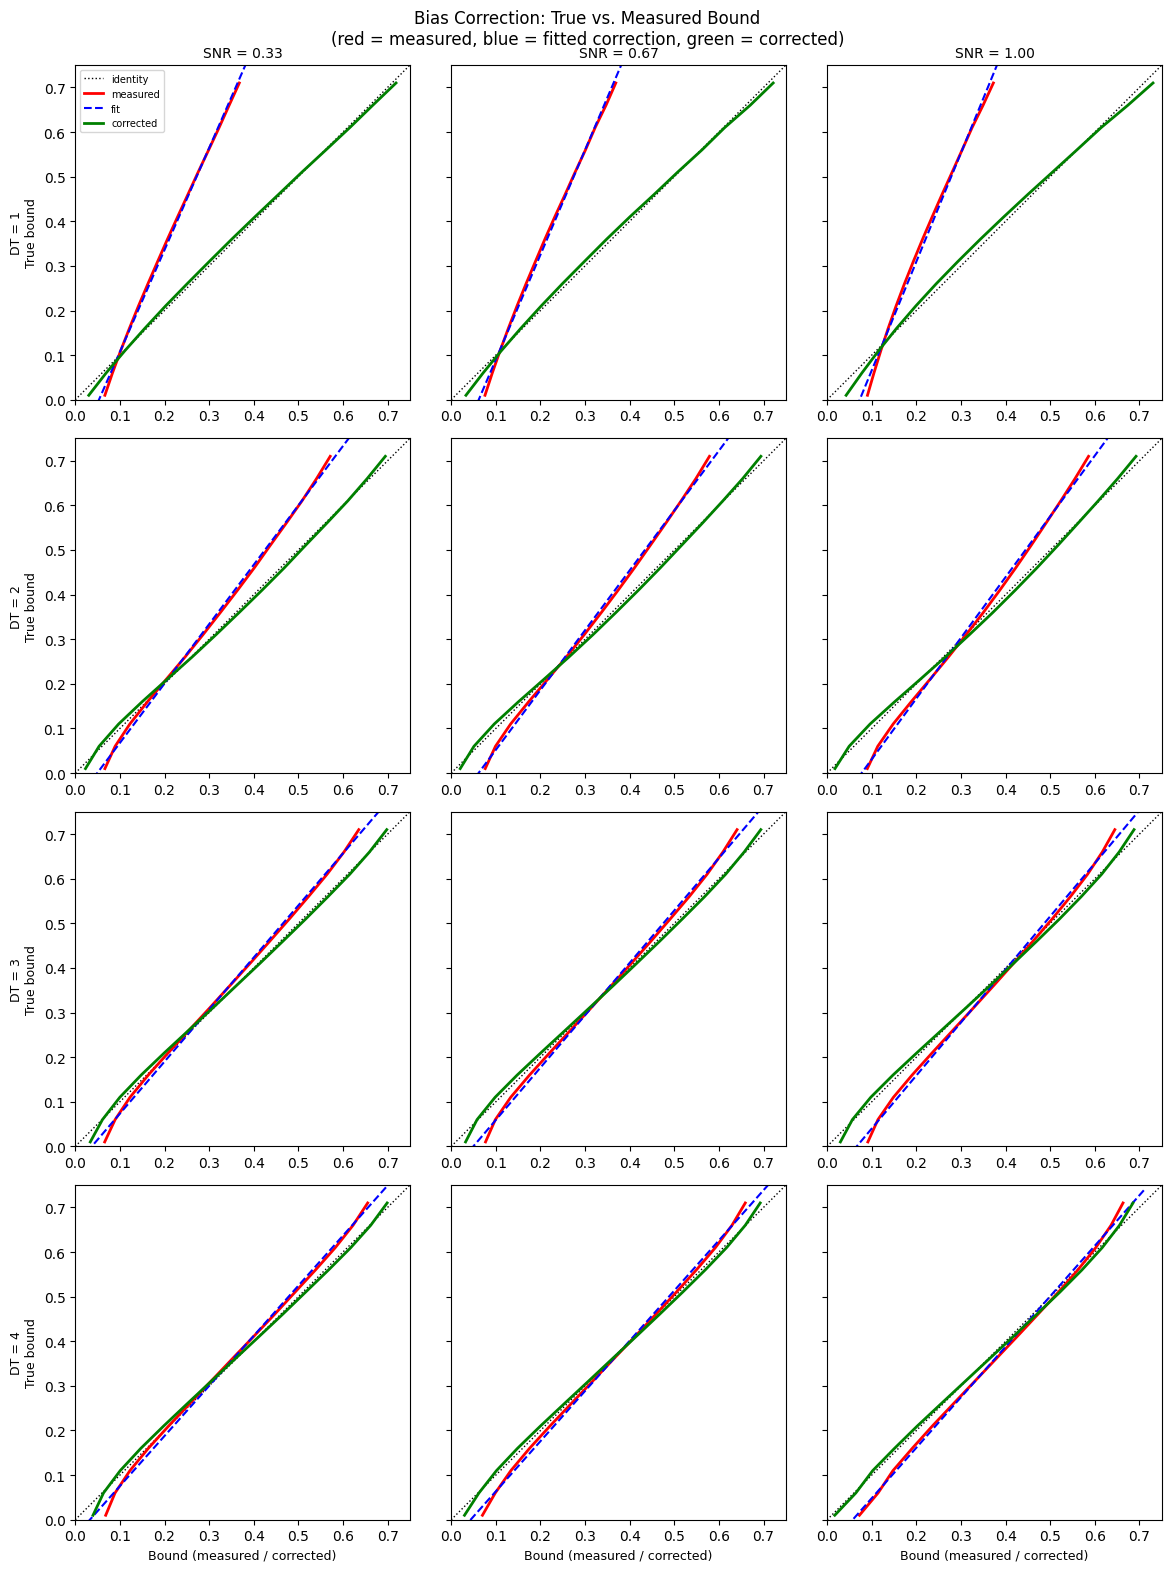

In [5]:
MAX_ROWS = 4   # show DT = 1 .. MAX_ROWS
MAX_COLS = n_means

fig, axs = plt.subplots(MAX_ROWS, MAX_COLS, figsize=(4 * MAX_COLS, 4 * MAX_ROWS))
if MAX_ROWS == 1:
    axs = axs[np.newaxis, :]
if MAX_COLS == 1:
    axs = axs[:, np.newaxis]
fig.suptitle(
    'Bias Correction: True vs. Measured Bound\n'
    '(red = measured, blue = fitted correction, green = corrected)',
    fontsize=12,
)

X_fit = np.column_stack([np.ones(len(SIM_BOUNDS)), SIM_BOUNDS])  # design matrix for prediction

for rt_idx in range(MAX_ROWS):
    for mm in range(MAX_COLS):
        ax = axs[rt_idx, mm]
        ax.plot([0, WALL], [0, WALL], 'k:', linewidth=1, label='identity')  # identity

        x     = bound_summary[:, rt_idx, mm]  # measured bound
        y     = SIM_BOUNDS                    # true bound
        valid = np.isfinite(x)

        if valid.sum() >= 2:
            # Red: uncorrected — plot measured (x-axis) vs true (y-axis)
            ax.plot(x[valid], y[valid], 'r-', linewidth=2, label='measured')

            coeffs = bias_correction[rt_idx, :, mm]
            if np.all(np.isfinite(coeffs)):
                # Blue: fitted line prediction at each true bound
                y_fit = X_fit @ coeffs  # = intercept + slope * SIM_BOUNDS
                ax.plot(SIM_BOUNDS, y_fit, 'b--', linewidth=1.5, label='fit')

                # Green: corrected — apply regression to measured bound
                x_corr = np.maximum(0.005, coeffs[0] + coeffs[1] * np.abs(x[valid]))
                ax.plot(x_corr, y[valid], 'g-', linewidth=2, label='corrected')

        ax.set_xlim(0, WALL)
        ax.set_ylim(0, WALL)
        ax.set_aspect('equal')

        if rt_idx == 0:
            ax.set_title(f'SNR = {SNRS[mm]:.2f}', fontsize=10)
        if mm == 0:
            ax.set_ylabel(f'DT = {rt_idx + 1}\nTrue bound', fontsize=9)
        else:
            ax.set_yticklabels([])
        if rt_idx == MAX_ROWS - 1:
            ax.set_xlabel('Bound (measured / corrected)', fontsize=9)
        if rt_idx == 0 and mm == 0:
            ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

## Summary figure: DT=2, lowest SNR

Replicates the summary panel in `makePigeon_biasCorrections.m` (the single-axis
figure at the end of that script).

- **x-axis**: Simulated (true) bound.
- **y-axis**: Measured (inferred) or corrected bound.
- **Gray line**: raw measured vs. true (shows the bias — measured deviates from true).
- **Blue line**: linear fit in the (true → measured) direction for display.
- **Black line**: corrected bound vs. true (should hug the identity).
- **Dotted**: identity.

Data shown: `n_sim_bounds` simulation points for DT=2, SNR = SNRS[0] (lowest
SNR level, where bias is largest). No additional filtering.

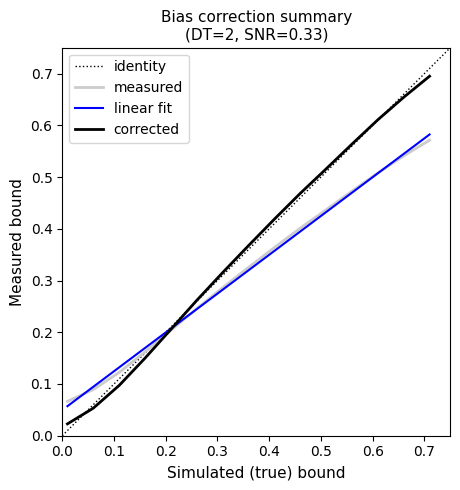

In [6]:
rt_idx = 1   # DT = 2 (0-indexed)
mm     = 0   # lowest SNR

x_true = SIM_BOUNDS
x_meas = bound_summary[:, rt_idx, mm]
valid  = np.isfinite(x_meas)

coeffs = bias_correction[rt_idx, :, mm]  # [intercept, slope]: true = a + b*measured
x_corr = np.maximum(0.005, coeffs[0] + coeffs[1] * np.abs(x_meas[valid]))

# Fit a display line in the (true → measured) direction for the MATLAB-style plot
A_disp = np.column_stack([np.ones(valid.sum()), x_true[valid]])
fit_meas, _, _, _ = np.linalg.lstsq(A_disp, x_meas[valid], rcond=None)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, WALL], [0, WALL], 'k:', linewidth=1, label='identity')
ax.plot(x_true[valid], x_meas[valid], '-', color='0.8', linewidth=2, label='measured')
ax.plot(x_true[valid], A_disp @ fit_meas,  'b-', linewidth=1.5, label='linear fit')
ax.plot(x_true[valid], x_corr,             'k-', linewidth=2,   label='corrected')

ax.set_xlim(0, WALL)
ax.set_ylim(0, WALL)
ax.set_aspect('equal')
ax.set_xlabel('Simulated (true) bound', fontsize=11)
ax.set_ylabel('Measured bound', fontsize=11)
ax.set_title(
    f'Bias correction summary\n(DT={rt_idx+1}, SNR={SNRS[mm]:.2f})',
    fontsize=11,
)
ax.legend()
plt.tight_layout()
plt.show()

---
## Hypothesis testing: origin of the kink

The measured-vs-true bound curves (red lines above) show a non-linearity: a shallower
regime for small bounds and a steeper regime for large bounds, with a sharp kink between
them. This section documents the investigation into the cause of that kink.

### Hypotheses tested

**H1 (first-passage selection, μ×DT scale):** kink occurs near B ≈ μ×DT.
*Ruled out*: kink location did not separate by SNR or scale with DT.

**H2 (NDT heterogeneity):** kink arises because the algorithm picks a single lag `k`
for all trials while true NDT varies across trials ({1, 2, 3}), misclassifying
NDT=2,3 trials into wrong DT bins and computing bounds from post-crossing positions.
*Initially incorrectly ruled out* (evidence was contaminated by the tie-breaking bug
described below). **Confirmed correct** once the bug was fixed: the fixed-NDT=1
simulation is kink-free, while the NDT∈{1,2,3} simulation retains the kink.

**Revised H1 (σ scale):** kink occurs near B ≈ σ. *Partially supported* in the
correct order, but the apparent kink in those tests was actually the tie-breaking bug.

**Root cause of apparent kink in fixed-NDT=1 tests — congruence lag tie-breaking bug:**
when B is large enough that no trial produces a sign-flip at lag `k=0`, both `k=0` and
`k=1` achieve congruence=1.0. `np.nanargmax` returns the *first* tied maximum (`k=0`),
applying zero NDT correction, shifting trials into wrong DT bins, and computing bounds
from post-crossing positions. This is a **sample-size artifact**: the threshold scales
with σ and shifts with n_trials, approximately:
```
B_kink ≳ (|Φ⁻¹(1/n_trials)| × σ − μ) / 2
```

### Fix applied

Changed lag selection in both `pigeon/data.py` (`get_bounds`) and the notebook helper
`infer_bound_mean_per_dt` to pick the **largest** lag achieving maximum congruence:
```python
# Before (buggy):
ci = np.nanargmax(congruences)

# After (fixed):
max_cong = np.nanmax(congruences)
ci = int(np.where(congruences == max_cong)[0][-1])
```

### Residual kink (H2)

After the bug fix, the original simulation (NDT∈{1,2,3}) still shows a kink. This is
the true H2 effect: using `ci=1` for all trials while NDT_true∈{1,2,3} causes
NDT=2,3 trials to be assigned to DT bins one or two steps too late, with their bounds
computed from post-crossing positions (overestimates by ≈ μ/2 and μ respectively).
The bias correction matrix (`boundBiasCorrection.mat`) accounts for this residual kink.

## Hypothesis 1 test: kink location vs DT

Hypothesis 1 predicts that the kink in the measured-vs-true bound curve occurs near the "natural" bound
`B_nat = μ × DT` — the expected DV position after `DT` steps under the drift `μ`.

For each (DT, SNR) cell, we fit a two-segment piecewise linear model to the red curve
(measured bound on x, true bound on y) by exhaustive search over candidate breakpoints,
minimizing the combined OLS residual sum of squares across both segments.
The detected kink location (in true-bound units) is then compared to `μ × DT`.

If H1 is correct, the solid lines (detected kink) should track the dashed lines (predicted `μ × DT`),
with each SNR level producing a distinct linear relationship.

In [ ]:
if not RUN_HYPOTHESIS_TESTS:
    raise SystemExit("Hypothesis tests disabled — set RUN_HYPOTHESIS_TESTS=True to run")

def find_kink_true_bound(measured, true_bounds, min_segment=3):
    """
    Fit a two-segment piecewise linear model to the measured (x) vs true (y)
    bound curve. Returns the true-bound value at the optimal breakpoint.

    Tries all candidate split indices via exhaustive search; minimizes the
    combined OLS residual sum of squares across both segments.
    Returns NaN if too few valid points exist (need >= 2*min_segment + 1).
    """
    valid = np.isfinite(measured)
    xv, yv = measured[valid], true_bounds[valid]
    n = len(xv)
    if n < 2 * min_segment + 1:
        return np.nan

    best_rss, best_kink = np.inf, np.nan
    for k in range(min_segment, n - min_segment):
        rss = 0.0
        for xs, ys in [(xv[:k + 1], yv[:k + 1]), (xv[k:], yv[k:])]:
            A = np.column_stack([np.ones(len(xs)), xs])
            c, _, _, _ = np.linalg.lstsq(A, ys, rcond=None)
            rss += np.sum((ys - A @ c) ** 2)
        if rss < best_rss:
            best_rss, best_kink = rss, yv[k]

    return best_kink


# Compute detected kink location for every (DT, SNR) cell
kink_loc = np.full((MAX_RT, n_means), np.nan)
for mm in range(n_means):
    for rt_idx in range(MAX_RT):
        kink_loc[rt_idx, mm] = find_kink_true_bound(
            bound_summary[:, rt_idx, mm], SIM_BOUNDS
        )

# Plot detected kink vs DT, overlaid with H1 prediction B_nat = μ × DT
dt_axis = np.arange(1, MAX_RT + 1)
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(7, 5))

for mm in range(n_means):
    mu, snr = GENERATIVE_MEANS[mm], SNRS[mm]
    c = colors[mm]
    ax.plot(dt_axis, kink_loc[:, mm], 'o-', color=c, linewidth=1.5, markersize=5,
            label=f'SNR={snr:.2f}  detected')
    ax.plot(dt_axis, np.minimum(mu * dt_axis, WALL), '--', color=c, alpha=0.5,
            linewidth=1.5, label=f'SNR={snr:.2f}  B_nat = μ×DT')

ax.axhline(WALL, color='k', linestyle=':', linewidth=1, alpha=0.4)
ax.text(MAX_RT - 0.2, WALL + 0.01, 'wall', fontsize=8, ha='right', va='bottom')
ax.set_xlabel('DT bin', fontsize=11)
ax.set_ylabel('Kink location (true bound)', fontsize=11)
ax.set_title(
    'Kink location vs DT\n(solid = detected via piecewise linear fit;  dashed = H1 prediction μ × DT)',
    fontsize=11,
)
ax.set_xlim(0.5, MAX_RT + 0.5)
ax.set_ylim(0, WALL + 0.05)
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

## Hypothesis 2 test: fixed NDT = 1

H2 claims the kink arises from NDT heterogeneity: the algorithm picks a single lag `k`
for all trials, but true NDT varies across trials ({1, 2, 3}), so some midpoints are
computed from the wrong DV columns.

**Test**: rerun the same simulations with `ndt_min = ndt_max = 1` (every trial has NDT = 1).
The algorithm will consistently find `k = 1`, there is no per-trial mismatch, and H2's
proposed mechanism is entirely absent.

- If the kink **disappears** → H2 is supported.
- If the kink **persists** → the kink has a different cause (H2 is not sufficient).

**Note on prior result:** An earlier run of this test (before the lag tie-breaking bug was
fixed) incorrectly concluded that H2 was ruled out. The kink appeared to persist with
fixed NDT=1, but was actually caused by the tie-breaking bug (see n_trials test below):
`np.nanargmax` was selecting `k=0` instead of `k=1` when both achieved congruence=1.0.
With the bug fixed, the fixed-NDT=1 simulation produces a **smooth, kink-free** curve.
The original simulation (NDT∈{1,2,3}) still shows a kink — confirming that H2 is the
correct explanation.

**H2 mechanism (confirmed):** with NDT∈{1,2,3} and `ci=1` selected for all trials:
- NDT_true=1 trials → DT_est = DT_true ✓ — midpoint at crossing ≈ B
- NDT_true=2 trials → DT_est = DT_true + 1 — midpoint one step *after* crossing ≈ B + μ/2
- NDT_true=3 trials → DT_est = DT_true + 2 — midpoint two steps *after* crossing ≈ B + μ

The misclassified NDT=2,3 trials inflate the mean inferred bound, and the degree of
inflation varies with B (because the composition of each DT_est bin changes across the
bound range), producing the kink.

In [ ]:
if not RUN_HYPOTHESIS_TESTS:
    raise SystemExit("Hypothesis tests disabled — set RUN_HYPOTHESIS_TESTS=True to run")

# Rerun simulations with fixed NDT = 1 (no NDT heterogeneity)
bound_summary_ndt1 = np.full((n_sim_bounds, MAX_RT, n_means), np.nan)

rng_ndt1 = np.random.default_rng(42)  # same seed as original for comparability

for mm, gen_mean in enumerate(GENERATIVE_MEANS):
    snr = gen_mean / GENERATIVE_STD
    print(f'\nSNR {mm+1}/{n_means}  (generative_mean={gen_mean:.2f}, SNR={snr:.3f})')

    for ss, sim_bound in enumerate(SIM_BOUNDS):
        print(f'  bound {ss+1:2d}/{n_sim_bounds}: {sim_bound:.2f}', end='\r')

        choices, rts, DV, _, _, _, _ = simulate_trials(
            generative_mean = gen_mean,
            generative_std  = GENERATIVE_STD,
            num_trials      = NUM_TRIALS,
            max_steps       = MAX_STEPS,
            bound_mean      = sim_bound,
            bound_std       = 0.0,
            bound_max       = WALL,
            ndt_min         = 1,
            ndt_max         = 1,   # ← fixed NDT, no heterogeneity
            rng             = rng_ndt1,
            return_steps    = False,
        )

        bound_summary_ndt1[ss, :, mm] = infer_bound_mean_per_dt(
            choices, rts, DV,
            max_ndt = MAX_NDT,
            max_rt  = MAX_RT,
            wall    = WALL,
        )

    print(f'  done ({n_sim_bounds} bounds completed)         ')

print('\nSimulation complete (fixed NDT=1).')


# ── Side-by-side comparison: original (NDT∈{1,2,3}) vs fixed (NDT=1) ────────
MAX_ROWS = 4
fig, axs = plt.subplots(MAX_ROWS, n_means, figsize=(4 * n_means, 4 * MAX_ROWS))
fig.suptitle(
    'H2 test: measured vs true bound\n'
    '(red = original NDT∈{1,2,3};  blue = fixed NDT=1;  dotted = identity)',
    fontsize=12,
)

for rt_idx in range(MAX_ROWS):
    for mm in range(n_means):
        ax = axs[rt_idx, mm]
        ax.plot([0, WALL], [0, WALL], 'k:', linewidth=1)

        x_orig = bound_summary[:, rt_idx, mm]
        x_ndt1 = bound_summary_ndt1[:, rt_idx, mm]
        y      = SIM_BOUNDS

        if np.isfinite(x_orig).sum() >= 2:
            ax.plot(x_orig[np.isfinite(x_orig)], y[np.isfinite(x_orig)],
                    'r-', linewidth=2, label='NDT∈{1,2,3}')
        if np.isfinite(x_ndt1).sum() >= 2:
            ax.plot(x_ndt1[np.isfinite(x_ndt1)], y[np.isfinite(x_ndt1)],
                    'b-', linewidth=2, label='NDT=1')

        ax.set_xlim(0, WALL)
        ax.set_ylim(0, WALL)
        ax.set_aspect('equal')

        if rt_idx == 0:
            ax.set_title(f'SNR = {SNRS[mm]:.2f}', fontsize=10)
        if mm == 0:
            ax.set_ylabel(f'DT = {rt_idx + 1}\nTrue bound', fontsize=9)
        else:
            ax.set_yticklabels([])
        if rt_idx == MAX_ROWS - 1:
            ax.set_xlabel('Measured bound', fontsize=9)
        if rt_idx == 0 and mm == 0:
            ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

## Revised H1 test: kink location tracks σ, not μ or DT

With NDT heterogeneity ruled out, the kink must arise from first-passage geometry.
The revised hypothesis is that the kink occurs near **B ≈ σ** (the per-step standard deviation):

- **B < σ**: a single step can jump over B from far below — pre-crossing position DV[DT−1]
  can be anywhere in [0, B], so undershoot is large and variable.
- **B > σ**: the step is small relative to B — DV[DT−1] must already be close to B to cross,
  so undershoot is small.

Since σ is fixed at 0.15 in all original conditions, the kink should appear at B ≈ 0.15
regardless of DT or SNR — consistent with what we observed.

**Test**: fix μ = 0.10 and NDT = 1, vary σ ∈ {0.10, 0.15, 0.20}.
If the revised hypothesis is correct, the kink location should shift proportionally with σ,
with the kink appearing near B = σ for each condition.

In [ ]:
if not RUN_HYPOTHESIS_TESTS:
    raise SystemExit("Hypothesis tests disabled — set RUN_HYPOTHESIS_TESTS=True to run")

TEST_STDS  = [0.10, 0.15, 0.20]   # σ values to test
TEST_MEAN  = 0.10                  # fixed μ (mid-range SNR)
TEST_DT_ROWS = [1, 3, 5, 7]       # DT bins to show (0-indexed → DT = 2, 4, 6, 8)

# Run simulations for each σ, storing mean inferred bound per (sim_bound, DT)
bound_summary_sigma = {}   # keyed by σ

rng_sigma = np.random.default_rng(42)

for std in TEST_STDS:
    print(f'\nσ = {std:.2f}  (SNR = {TEST_MEAN/std:.2f})')
    bs = np.full((n_sim_bounds, MAX_RT), np.nan)

    for ss, sim_bound in enumerate(SIM_BOUNDS):
        print(f'  bound {ss+1:2d}/{n_sim_bounds}: {sim_bound:.2f}', end='\r')

        choices, rts, DV, _, _, _, _ = simulate_trials(
            generative_mean = TEST_MEAN,
            generative_std  = std,
            num_trials      = NUM_TRIALS,
            max_steps       = MAX_STEPS,
            bound_mean      = sim_bound,
            bound_std       = 0.0,
            bound_max       = WALL,
            ndt_min         = 1,
            ndt_max         = 1,
            rng             = rng_sigma,
            return_steps    = False,
        )

        bs[ss, :] = infer_bound_mean_per_dt(
            choices, rts, DV,
            max_ndt = MAX_NDT,
            max_rt  = MAX_RT,
            wall    = WALL,
        )

    bound_summary_sigma[std] = bs
    print(f'  done ({n_sim_bounds} bounds completed)         ')

print('\nDone.')


# ── Plot: measured vs true for each σ, one panel per DT row ─────────────────
colors_sigma = {0.10: 'tab:blue', 0.15: 'tab:orange', 0.20: 'tab:green'}

fig, axs = plt.subplots(1, len(TEST_DT_ROWS), figsize=(4.5 * len(TEST_DT_ROWS), 4.5))
fig.suptitle(
    'Revised H1 test: does kink location track σ?\n'
    '(μ = 0.10, NDT = 1 fixed;  horizontal dashed lines mark true bound B = σ)',
    fontsize=12,
)

for col, rt_idx in enumerate(TEST_DT_ROWS):
    ax = axs[col]
    ax.plot([0, WALL], [0, WALL], 'k:', linewidth=1, label='identity')

    for std in TEST_STDS:
        x = bound_summary_sigma[std][:, rt_idx]
        y = SIM_BOUNDS
        valid = np.isfinite(x)
        if valid.sum() >= 2:
            ax.plot(x[valid], y[valid], '-', color=colors_sigma[std],
                    linewidth=2, label=f'σ={std:.2f}')
        # Horizontal line at predicted kink: true bound B = σ
        ax.axhline(std, color=colors_sigma[std], linestyle='--',
                   linewidth=1, alpha=0.7)

    ax.set_xlim(0, WALL)
    ax.set_ylim(0, WALL)
    ax.set_aspect('equal')
    ax.set_title(f'DT = {rt_idx + 1}', fontsize=10)
    ax.set_xlabel('Measured bound', fontsize=9)
    if col == 0:
        ax.set_ylabel('True bound', fontsize=9)
        ax.legend(fontsize=8, loc='upper left')
    else:
        ax.set_yticklabels([])

plt.tight_layout()
plt.show()

## N_trials test: kink location is a sample-size artifact

The kink arises because `np.nanargmax` returns the **first** tied maximum. When B is large
enough that no simulated trial produces a sign-flip at lag `k=0`, both `k=0` and `k=1`
achieve congruence = 1.0, and `nanargmax` returns `k=0` — the wrong lag.

The sign-flip condition at lag `k=0` is:
```
step < −2 × DV[DT]
```
where `DV[DT] ≥ B` is the actual crossing position (not B itself). Because of overshoot,
`E[DV[DT]] > B`, so sign flips become negligible at a **lower** B than a formula based
on B alone would predict. The tie (and hence the kink) occurs when:
```
P(N(μ, σ²) < −2·E[DV[DT]]) < 1/n_trials
```
There is no closed form since `E[DV[DT]]` depends on B, but a lower-bound approximation
(substituting B for `E[DV[DT]]`) gives:
```
B_kink ≳ (|Φ⁻¹(1/n_trials)| × σ − μ) / 2
```
Because `E[DV[DT]] > B`, the true transition happens at a **lower** B than this formula
predicts — compressing the n=10K and n=100K transitions into the same SIM_BOUNDS interval.

**Prediction**: with σ=0.15 and μ=0.10, the lower-bound approximation gives:

| n_trials | \|Φ⁻¹(1/n)| | B_kink lower bound |
|---------|------------|--------|
| 10 K    | 3.72       | ≈ 0.23 |
| 100 K   | 4.42       | ≈ 0.27 |
| 1 M     | 4.89       | ≈ 0.31 |

The first two predictions both round to the same SIM_BOUNDS interval (transition at B=0.26),
while the 1M prediction rounds to B=0.31 — consistent with the observed lag transitions.

In [ ]:
if not RUN_HYPOTHESIS_TESTS:
    raise SystemExit("Hypothesis tests disabled — set RUN_HYPOTHESIS_TESTS=True to run")

from scipy.stats import norm as sp_norm

TEST_N_TRIALS = [10_000, 100_000, 1_000_000]
TEST_STD_NT   = 0.15
TEST_MEAN_NT  = 0.10
TEST_DT_NT    = 3   # 0-indexed → DT = 4

# Analytical kink prediction for each n_trials
def predicted_kink(n, mu, sigma):
    return (abs(sp_norm.ppf(1 / n)) * sigma - mu) / 2

colors_n = {10_000: 'tab:blue', 100_000: 'tab:orange', 1_000_000: 'tab:green'}

# Run simulations
bound_summary_n = {}
selected_lags   = {}

rng_n = np.random.default_rng(42)

for n in TEST_N_TRIALS:
    print(f'\nn_trials = {n:,}  (predicted kink ≈ {predicted_kink(n, TEST_MEAN_NT, TEST_STD_NT):.3f})')
    bs   = np.full((n_sim_bounds, MAX_RT), np.nan)
    lags = []

    for ss, sim_bound in enumerate(SIM_BOUNDS):
        print(f'  bound {ss+1:2d}/{n_sim_bounds}: {sim_bound:.2f}', end='\r')

        choices, rts, DV, _, _, _, _ = simulate_trials(
            generative_mean = TEST_MEAN_NT,
            generative_std  = TEST_STD_NT,
            num_trials      = n,
            max_steps       = MAX_STEPS,
            bound_mean      = sim_bound,
            bound_std       = 0.0,
            bound_max       = WALL,
            ndt_min         = 1,
            ndt_max         = 1,
            rng             = rng_n,
            return_steps    = False,
        )

        # Reproduce lag selection to record which lag was chosen
        choices_pm   = np.where(np.isfinite(choices), choices * 2 - 1, 0)
        bmat         = np.zeros((n, MAX_NDT))
        for k in range(MAX_NDT):
            rows = np.where(rts >= k + 2)[0]
            if len(rows):
                r = rts[rows]
                bmat[rows, k] = (DV[rows, r - 1 - k] + DV[rows, r - 2 - k]) / 2
        cong = np.full(MAX_NDT, np.nan)
        for k in range(MAX_NDT):
            lc = bmat[:, k] != 0
            if lc.sum() > 5:
                cong[k] = np.mean(np.sign(bmat[lc, k]) == choices_pm[lc])
        max_cong = np.nanmax(cong)
        ci = int(np.where(cong == max_cong)[0][-1])
        lags.append(ci)

        bs[ss, :] = infer_bound_mean_per_dt(
            choices, rts, DV, max_ndt=MAX_NDT, max_rt=MAX_RT, wall=WALL,
        )

    bound_summary_n[n] = bs
    selected_lags[n]   = lags
    print(f'  done                                   ')

print('\nDone.')


# ── Plot 1: measured vs true for DT=4, one curve per n_trials ───────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot([0, WALL], [0, WALL], 'k:', linewidth=1, label='identity')

for n in TEST_N_TRIALS:
    x     = bound_summary_n[n][:, TEST_DT_NT]
    valid = np.isfinite(x)
    bkink = predicted_kink(n, TEST_MEAN_NT, TEST_STD_NT)
    c     = colors_n[n]
    ax.plot(x[valid], SIM_BOUNDS[valid], '-', color=c, linewidth=2,
            label=f'n={n:,}')
    ax.axhline(bkink, color=c, linestyle='--', linewidth=1, alpha=0.7,
               label=f'predicted B_kink={bkink:.2f}')

ax.set_xlim(0, WALL); ax.set_ylim(0, WALL); ax.set_aspect('equal')
ax.set_xlabel('Measured bound', fontsize=10)
ax.set_ylabel('True bound', fontsize=10)
ax.set_title(f'DT = {TEST_DT_NT + 1}  (σ=0.15, μ=0.10, NDT=1 fixed)\n'
             f'dashed lines = predicted kink B ≈ (|Φ⁻¹(1/n)|×σ − μ)/2', fontsize=9)
ax.legend(fontsize=8)


# ── Plot 2: selected congruence lag vs true bound for each n_trials ──────────
ax2 = axes[1]
for n in TEST_N_TRIALS:
    ax2.plot(SIM_BOUNDS, selected_lags[n], 'o-', color=colors_n[n],
             linewidth=1.5, markersize=5, label=f'n={n:,}')
    bkink = predicted_kink(n, TEST_MEAN_NT, TEST_STD_NT)
    ax2.axvline(bkink, color=colors_n[n], linestyle='--', linewidth=1, alpha=0.7)

ax2.set_xlabel('True bound (sim_bound)', fontsize=10)
ax2.set_ylabel('Selected congruence lag (ci)', fontsize=10)
ax2.set_title('Selected lag drops from 1→0 at the predicted kink\n'
              '(dashed = predicted transition)', fontsize=9)
ax2.set_yticks([0, 1, 2])
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Option 2 test: marginal bound estimator

Instead of picking a single best lag `ci` for all trials, compute a **weighted average
of `bound_matrix` columns** using uniform weights over the known NDT range {1, 2, 3}.
DT is assigned using the expected NDT = (1+3)/2 = 2.

For each trial `i`:
```
bound_marginal[i] = (1/3) × bound_matrix[i,1]  +  (1/3) × bound_matrix[i,2]  +  (1/3) × bound_matrix[i,3]
DT_est[i]         = RT[i] − 2 − 1  =  RT[i] − 3
```

The bound at lag `k` estimates the midpoint at position `RT−1−k` in the DV. For a trial
with NDT_true = j:
- `k = j`: midpoint at the actual crossing → unbiased estimate of B
- `k < j`: midpoint from post-crossing positions → overestimates B by ≈ (j−k) × μ
- `k > j`: midpoint from pre-crossing positions → underestimates B

Averaging across k=1,2,3 mixes these biases. The overestimates (k < j) and underestimates
(k > j) partially cancel, and the remaining bias is **roughly constant across bound values**
rather than varying with the DT-bin composition — which should eliminate or reduce the kink.

**Test**: run the full simulation with `marginal=True` (using 200K trials for speed) and
compare the measured-vs-true curves to the single-lag estimator.

In [ ]:
if not RUN_HYPOTHESIS_TESTS:
    raise SystemExit("Hypothesis tests disabled — set RUN_HYPOTHESIS_TESTS=True to run")

N_MARGINAL   = 200_000   # trials per run (reduced for speed)
MAX_ROWS_CMP = 4         # DT rows to show

bound_summary_marginal  = np.full((n_sim_bounds, MAX_RT, n_means), np.nan)
bound_summary_single200 = np.full((n_sim_bounds, MAX_RT, n_means), np.nan)

rng_m = np.random.default_rng(42)

for mm, gen_mean in enumerate(GENERATIVE_MEANS):
    print(f'\nSNR {mm+1}/{n_means}  (μ={gen_mean:.2f})')
    for ss, sim_bound in enumerate(SIM_BOUNDS):
        print(f'  bound {ss+1:2d}/{n_sim_bounds}: {sim_bound:.2f}', end='\r')

        choices, rts, DV, _, _, _, _ = simulate_trials(
            generative_mean = gen_mean,
            generative_std  = GENERATIVE_STD,
            num_trials      = N_MARGINAL,
            max_steps       = MAX_STEPS,
            bound_mean      = sim_bound,
            bound_std       = 0.0,
            bound_max       = WALL,
            ndt_min         = NDT_MIN,
            ndt_max         = NDT_MAX,
            rng             = rng_m,
            return_steps    = False,
        )

        bound_summary_single200[ss, :, mm] = infer_bound_mean_per_dt(
            choices, rts, DV, max_ndt=MAX_NDT, max_rt=MAX_RT, wall=WALL,
            marginal=False,
        )
        bound_summary_marginal[ss, :, mm] = infer_bound_mean_per_dt(
            choices, rts, DV, max_ndt=MAX_NDT, max_rt=MAX_RT, wall=WALL,
            marginal=True, ndt_min=NDT_MIN, ndt_max=NDT_MAX,
        )

    print(f'  done ({n_sim_bounds} bounds)         ')

print('\nDone.')


# ── Plot: single-lag vs marginal for DT bins 1–4 × all SNRs ─────────────────
fig, axs = plt.subplots(MAX_ROWS_CMP, n_means,
                        figsize=(4 * n_means, 4 * MAX_ROWS_CMP))
fig.suptitle(
    'Marginal estimator vs single-lag\n'
    '(red = single-lag;  blue = marginal;  dotted = identity)',
    fontsize=12,
)

for rt_idx in range(MAX_ROWS_CMP):
    for mm in range(n_means):
        ax = axs[rt_idx, mm]
        ax.plot([0, WALL], [0, WALL], 'k:', linewidth=1)

        x_s = bound_summary_single200[:, rt_idx, mm]
        x_m = bound_summary_marginal[:, rt_idx, mm]
        y   = SIM_BOUNDS

        if np.isfinite(x_s).sum() >= 2:
            ax.plot(x_s[np.isfinite(x_s)], y[np.isfinite(x_s)],
                    'r-', linewidth=2, label='single-lag')
        if np.isfinite(x_m).sum() >= 2:
            ax.plot(x_m[np.isfinite(x_m)], y[np.isfinite(x_m)],
                    'b-', linewidth=2, label='marginal')

        ax.set_xlim(0, WALL); ax.set_ylim(0, WALL); ax.set_aspect('equal')
        if rt_idx == 0:
            ax.set_title(f'SNR = {SNRS[mm]:.2f}', fontsize=10)
        if mm == 0:
            ax.set_ylabel(f'DT = {rt_idx + 1}\nTrue bound', fontsize=9)
        else:
            ax.set_yticklabels([])
        if rt_idx == MAX_ROWS_CMP - 1:
            ax.set_xlabel('Measured bound', fontsize=9)
        if rt_idx == 0 and mm == 0:
            ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

## NDT distribution test

How does the measured-vs-true bound relationship depend on the true NDT distribution,
and on mismatch between the true and assumed range?

Five conditions:

| | True NDT | Assumed range | Purpose |
|--|----------|---------------|---------|
| **A** | fixed = 2 | {2,2} | No variability |
| **B** | U{1,2} | {1,2} | Smaller spread, correct spec |
| **C** | U{1,2,3} | {1,3} | Baseline |
| **D** | U{1,2,3,4} | {1,4} | Larger spread, correct spec |
| **E** | U{1,2} | {1,3} | **Misspecification** (same true as B, wider assumed) |

For the **congruence** estimator the assumed range has no effect (B ≡ E), so five curves
reduce to four. For the **marginal** estimator, E vs B directly shows the cost of
over-specifying the NDT range.

**H2 prediction**: kink magnitude should increase monotonically with NDT spread (A < B < C < D),
and misspecification (E) should be at least as bad as the correct wider range (C).


In [ ]:
if not RUN_HYPOTHESIS_TESTS:
    raise SystemExit("Hypothesis tests disabled — set RUN_HYPOTHESIS_TESTS=True to run")

N_NDT_TEST   = 200_000
MAX_ROWS_NDT = 4
mm_plot      = n_means // 2   # middle SNR for display

conditions = [
    dict(id='A', label='A: fixed NDT=2',           true_min=2, true_max=2, est_min=2, est_max=2, color='k',            ls='-'),
    dict(id='B', label='B: U{1,2}, correct',       true_min=1, true_max=2, est_min=1, est_max=2, color='royalblue',   ls='-'),
    dict(id='C', label='C: U{1,2,3}, baseline',    true_min=1, true_max=3, est_min=1, est_max=3, color='forestgreen', ls='-'),
    dict(id='D', label='D: U{1,2,3,4}, correct',   true_min=1, true_max=4, est_min=1, est_max=4, color='darkorange',  ls='-'),
    dict(id='E', label='E: U{1,2}, assume {1,3}',  true_min=1, true_max=2, est_min=1, est_max=3, color='crimson',     ls='--'),
]

# Results: (n_conditions, n_sim_bounds, MAX_RT, n_means)
ndt_cong = np.full((len(conditions), n_sim_bounds, MAX_RT, n_means), np.nan)
ndt_marg = np.full((len(conditions), n_sim_bounds, MAX_RT, n_means), np.nan)

rng_ndt = np.random.default_rng(42)

for ci, cond in enumerate(conditions):
    print(f"\nCondition {cond['id']}: {cond['label']}")
    for mm, gen_mean in enumerate(GENERATIVE_MEANS):
        for ss, sim_bound in enumerate(SIM_BOUNDS):
            choices, rts, DV, _, _, _, _ = simulate_trials(
                generative_mean=gen_mean,
                generative_std=GENERATIVE_STD,
                num_trials=N_NDT_TEST,
                max_steps=MAX_STEPS,
                bound_mean=sim_bound,
                bound_std=0.0,
                bound_max=WALL,
                ndt_min=cond['true_min'],
                ndt_max=cond['true_max'],
                rng=rng_ndt,
                return_steps=False,
            )
            ndt_cong[ci, ss, :, mm] = infer_bound_mean_per_dt(
                choices, rts, DV,
                max_ndt=MAX_NDT, max_rt=MAX_RT, wall=WALL,
                marginal=False,
            )
            ndt_marg[ci, ss, :, mm] = infer_bound_mean_per_dt(
                choices, rts, DV,
                max_ndt=MAX_NDT, max_rt=MAX_RT, wall=WALL,
                marginal=True,
                ndt_min=cond['est_min'], ndt_max=cond['est_max'],
            )
        print(f'  SNR {mm+1}/{n_means} done')

print('\nDone.')

# ── Plot: congruence estimator (A–D; E is identical to B for congruence) ─────
fig, axs = plt.subplots(1, MAX_ROWS_NDT, figsize=(4 * MAX_ROWS_NDT, 4.5), sharey=True)
fig.suptitle(
    f'Congruence estimator — NDT distribution (SNR = {SNRS[mm_plot]:.2f})\n'
    'Conditions A–D only (E ≡ B for congruence estimator)',
    fontsize=11,
)
for rt_idx in range(MAX_ROWS_NDT):
    ax = axs[rt_idx]
    ax.plot([0, WALL], [0, WALL], 'k:', linewidth=1)
    for ci, cond in enumerate(conditions):
        if cond['id'] == 'E':       # duplicate of B for congruence — skip
            continue
        x = ndt_cong[ci, :, rt_idx, mm_plot]
        y = SIM_BOUNDS
        ok = np.isfinite(x)
        if ok.sum() >= 2:
            ax.plot(x[ok], y[ok], color=cond['color'], ls=cond['ls'],
                    linewidth=2, label=cond['label'])
    ax.set_xlim(0, WALL); ax.set_ylim(0, WALL); ax.set_aspect('equal')
    ax.set_title(f'DT = {rt_idx + 1}', fontsize=10)
    ax.set_xlabel('Measured bound', fontsize=9)
    if rt_idx == 0:
        ax.set_ylabel('True bound', fontsize=9)
        ax.legend(fontsize=7.5, loc='upper left')
plt.tight_layout()
plt.show()

# ── Plot: marginal estimator — show E vs B to isolate misspecification ────────
fig, axs = plt.subplots(1, MAX_ROWS_NDT, figsize=(4 * MAX_ROWS_NDT, 4.5), sharey=True)
fig.suptitle(
    f'Marginal estimator — NDT distribution (SNR = {SNRS[mm_plot]:.2f})\n'
    'Dashed red (E) vs solid blue (B): same true NDT {{1,2}}, different assumed range',
    fontsize=11,
)
for rt_idx in range(MAX_ROWS_NDT):
    ax = axs[rt_idx]
    ax.plot([0, WALL], [0, WALL], 'k:', linewidth=1)
    for ci, cond in enumerate(conditions):
        x = ndt_marg[ci, :, rt_idx, mm_plot]
        y = SIM_BOUNDS
        ok = np.isfinite(x)
        if ok.sum() >= 2:
            ax.plot(x[ok], y[ok], color=cond['color'], ls=cond['ls'],
                    linewidth=2, label=cond['label'])
    ax.set_xlim(0, WALL); ax.set_ylim(0, WALL); ax.set_aspect('equal')
    ax.set_title(f'DT = {rt_idx + 1}', fontsize=10)
    ax.set_xlabel('Measured bound', fontsize=9)
    if rt_idx == 0:
        ax.set_ylabel('True bound', fontsize=9)
        ax.legend(fontsize=7.5, loc='upper left')
plt.tight_layout()
plt.show()